# Exact - Lotka-Volterra

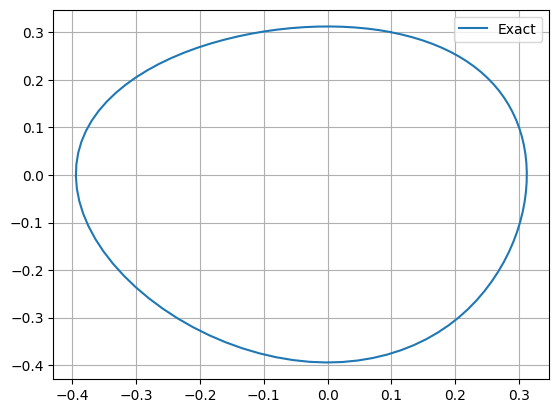

In [6]:
from scipy import linspace
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def ExactSyst(tspan, y):
    x1, x2 = y
    dx1 = x2 - x1*x2
    dx2 = -x1 + x1*x2
    return [dx1, dx2]

x0 = [0.1, 0.3]
ts, te = 0, 6.34 # 7s -> loop; >=10 -> many loops
t_exact = np.linspace(ts, te, 100)
sol_exact = solve_ivp(ExactSyst, [ts, te], x0, t_eval=t_exact)

## PLOTTING
plt.plot(sol_exact.y[0], sol_exact.y[1], label='Exact')
plt.legend()
plt.grid()
# plt.savefig("LV_exact.png") 
plt.show()

In [7]:
col1_exact = sol_exact.y[0]
col2_exact = sol_exact.y[1]

import csv
file_path = 'LV-exact.csv'

# Writing to CSV
with open(file_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['u1', 'u2'])  # Write header
    writer.writerows(zip(col1_exact, col2_exact))

# CLN2

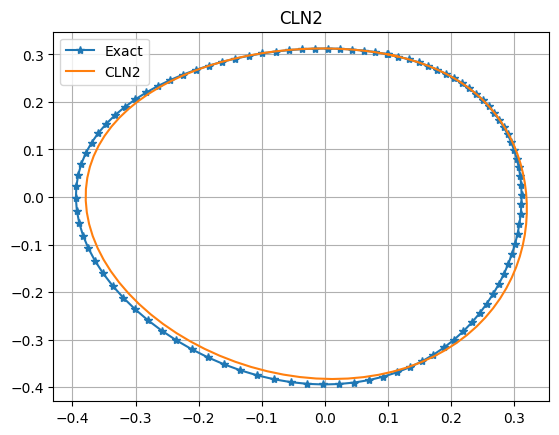

In [8]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define the linearized system of differential equations
def CLN2(t, y):
    x1, x2, x3, x4, x5 = y
    dx1 = x2 - x4
    dx2 = -x1 + x4
    dx3 = 2*x4
    dx4 = -x3 + x5
    dx5 = -2*x4
    return [dx1, dx2, dx3, dx4, dx5]

# Initial conditions
a, b = 0.1, 0.3
y0 = [a, b, a**2, a*b, b**2]

# t_span = np.linspace(ts, te, 100)
sol_CLN2 = solve_ivp(CLN2, [ts, te], y0, t_eval=t_exact)

# Plotting the results
plt.plot(sol_exact.y[0],sol_exact.y[1], marker='*', label='Exact')
plt.plot(sol_CLN2.y[0], sol_CLN2.y[1], label='CLN2')
plt.title('CLN2')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
col1_CLN2 = sol_CLN2.y[0]
col2_CLN2 = sol_CLN2.y[1]

import csv
file_path = 'LV-N2CL.csv'

# Writing to CSV
with open(file_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['u1', 'u2'])  # Write header
    writer.writerows(zip(col1_CLN2, col2_CLN2))

***

# CLN3

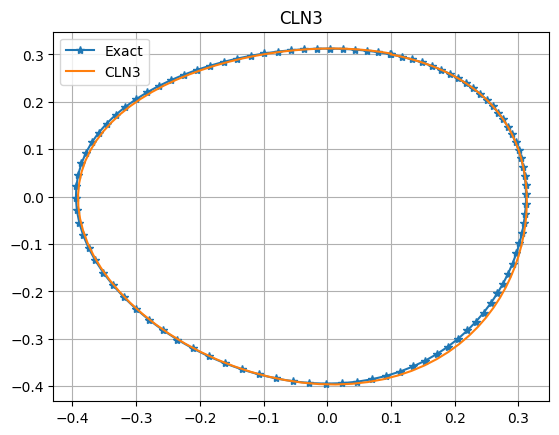

In [10]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define the ODE system
def CLN3(t, y):
    x1, x2, x3, x4, x5, x6, x7, x8, x9 = y
    dx1 = x2 - x4
    dx2 = -x1 + x4
    dx3 = 2 * x4 - 2 * x7
    dx4 = -x3 + x5 + x7 - x8
    dx5 = -2 * x4 + 2 * x8
    dx6 = 3 * x7
    dx7 = -x6 + 2 * x8
    dx8 = -2 * x7 + x9
    dx9 = -3 * x8
    
    return [dx1, dx2, dx3, dx4, dx5, dx6, dx7, dx8, dx9]

# Initial conditions
x0 = [a, b, a**2, a*b, b**2, a**3, (a**2)*b, a*(b**2), b**3]

# Time span
t_eval = np.linspace(ts, te, 100)

# Solve the system
sol_CLN3 = solve_ivp(CLN3, [ts, te], x0, t_eval=t_eval)

# Plot the solution
# Plotting the results
plt.plot(sol_exact.y[0],sol_exact.y[1], marker='*', label='Exact')
plt.plot(sol_CLN3.y[0], sol_CLN3.y[1], label='CLN3')
plt.title('CLN3')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
col1_CLN3 = sol_CLN3.y[0]
col2_CLN3 = sol_CLN3.y[1]

import csv
file_path = 'LV-N3CL.csv'

# Writing to CSV
with open(file_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['u1', 'u2'])  # Write header
    writer.writerows(zip(col1_CLN3, col2_CLN3))

***
# QN2

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from qade.bases import basis
from qade.equations import equation, solve
from qade.functions import function
from scipy.optimize import minimize

# Sample points at which the equation is to be evaluated
t = np.linspace(0, 1, 100)

# Define functions to solve using Carleman Linearization
u1, u2, u3, u4, u5 = function(n_in=1, n_out=5)

# Define the equations (translated from the CLN2 system)
Tscale = te  # Time scale factor
k1 = 4  # Scaling factor

eq1 = equation((u1[1] - (u2[0] - u4[0])*Tscale)/k1, t)
eq2 = equation((u2[1] - (-u1[0] + u4[0])*Tscale)/k1, t)
eq3 = equation((u3[1] - (2*u4[0])*Tscale)/k1, t)
eq4 = equation((u4[1] - (-u3[0] + u5[0])*Tscale)/k1, t)
eq5 = equation((u5[1] - (-2*u4[0])*Tscale)/k1, t)

# Define initial conditions
# a = -0.01
# b = 0.07
k2a = 6
k2 = 3

ic1 = equation((u1[0] - a)*k2a, 0)
ic2 = equation((u2[0] - b)*k2a, 0)
ic3 = equation((u3[0] - a**2)*k2, 0)
ic4 = equation((u4[0] - a*b)*k2, 0)
ic5 = equation((u5[0] - b**2)*k2, 0)

# Define Chebyshev basis
chebyshev_basis = basis("chebyshev", size_per_dim=14)

# Solve the system of equations
sol_QN2 = solve([eq1, eq2, eq3, eq4, eq5, ic1, ic2, ic3, ic4, ic5], 
              chebyshev_basis, 
              scales=1, 
              num_reads=400,  # Increased number of reads
              n_epochs=50, 
              n_spins=3, 
              classical_minimizer=minimize)

# Print results
print(f"loss = {sol_QN2.loss}, weights = {np.around(sol_QN2.weights, 2)}")

epoch = 0, loss = 439.82988666694786
epoch = 1, loss = 303.0865274042461
epoch = 2, loss = 283.14379480769315
epoch = 3, loss = 318.01156743044504
epoch = 4, loss = 622.6010841827648
epoch = 5, loss = 508.03960067316507
epoch = 6, loss = 381.53487448295647
epoch = 7, loss = 288.53868611860895
epoch = 8, loss = 595.2875098583061
epoch = 9, loss = 369.5949766411231
epoch = 10, loss = 254.00339443088436
epoch = 11, loss = 286.23018848743646
epoch = 12, loss = 247.58050672221358
epoch = 13, loss = 478.79176750603835
epoch = 14, loss = 283.1152406514772
epoch = 15, loss = 171.36801281073187
epoch = 16, loss = 194.96661752548945
epoch = 17, loss = 351.0067775816413
epoch = 18, loss = 340.52468367115824
epoch = 19, loss = 357.18132195814223
epoch = 20, loss = 284.168339505022
epoch = 21, loss = 277.75034081727625
epoch = 22, loss = 332.20861872584743
epoch = 23, loss = 347.47970278555675
epoch = 24, loss = 330.22173121250614
epoch = 25, loss = 244.46605306593207
epoch = 26, loss = 333.8170365

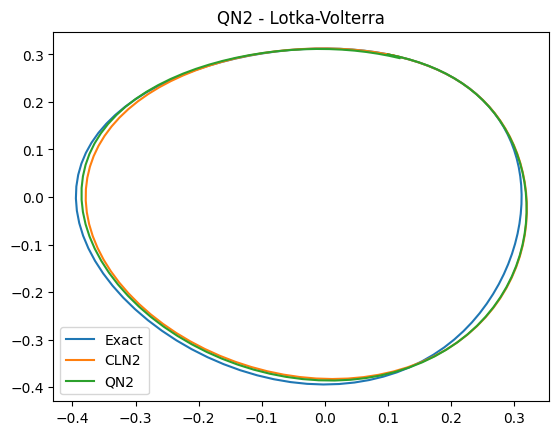

In [17]:
# Plotting the results for u1 and u2
plt.title('QN2 - Lotka-Volterra')
plt.plot(sol_exact.y[0], sol_exact.y[1], label='Exact')
plt.plot(sol_CLN2.y[0], sol_CLN2.y[1], label='CLN2')
plt.plot(sol_QN2(t)[:, 0], sol_QN2(t)[:, 1], label='QN2')
plt.legend()
# plt.grid(True)
# plt.savefig("LV_N2-Phase.png") 
plt.show()

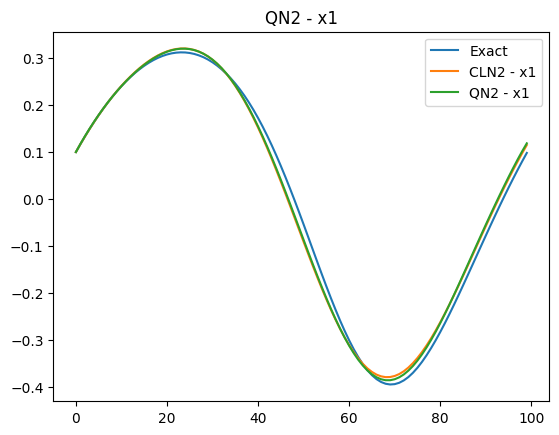

In [18]:
# Plotting the results for x1
plt.title('QN2 - x1')
plt.plot(sol_exact.y[0], label='Exact')
plt.plot(sol_CLN2.y[0], label='CLN2 - x1')
plt.plot(sol_QN2(t)[:, 0], label='QN2 - x1')
plt.legend()
# plt.savefig("LV_N2-x1.png") 

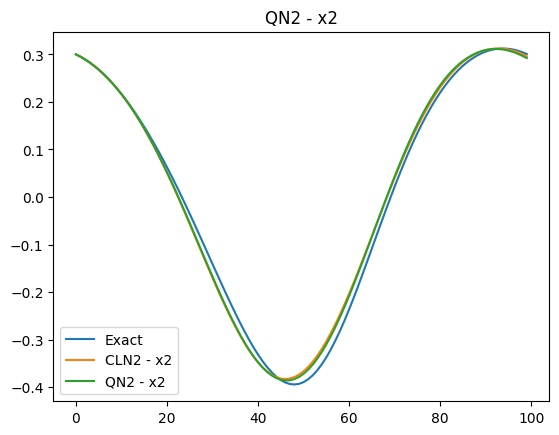

In [19]:
# Plotting the results for x2
plt.title('QN2 - x2')
plt.plot(sol_exact.y[1], label='Exact')
plt.plot(sol_CLN2.y[1], label='CLN2 - x2')
plt.plot(sol_QN2(t)[:, 1], label='QN2 - x2')
plt.legend()
# plt.savefig("LV_N2-x2.png") 

In [20]:
# column1Exact = sol_exact.y[0]
# column2Exact = sol_exact.y[1]

# import csv
# file_path = 'LV-N2Exact.csv'

# # Writing to CSV
# with open(file_path, 'w', newline='') as csvfile:
#     writer = csv.writer(csvfile)
#     writer.writerow(['u1', 'u2'])  # Write header
#     writer.writerows(zip(column1Exact, column2Exact))

In [21]:
# column1Classical = sol_CLN2.y[0]
# column2Classical = sol_CLN2.y[1]

# import csv
# file_path = 'LV-N2CL.csv'

# # Writing to CSV
# with open(file_path, 'w', newline='') as csvfile:
#     writer = csv.writer(csvfile)
#     writer.writerow(['u1', 'u2'])  # Write header
#     writer.writerows(zip(column1Classical, column1Classical))

In [22]:
col1QN2 = sol_QN2(t)[:, 0]
col2QN2 = sol_QN2(t)[:, 1]

import csv
file_path = 'LV-N2Q.csv'

# Writing to CSV
with open(file_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['u1', 'u2'])  # Write header
    writer.writerows(zip(col1QN2, col2QN2))

***

# QN3

In [30]:
import numpy as np
from qade.bases import basis
from qade.equations import equation, solve
from qade.functions import function
from scipy.optimize import minimize

# Parameters
Tscale = te
k1 = 2

# Sample points
t = np.linspace(0, 1, 100)

# Functions to solve for
x1, x2, x3, x4, x5, x6, x7, x8, x9 = function(n_in=1, n_out=9)

# Define the equations:
eq1 = equation((x1[1] - (x2[0] - x4[0])*Tscale)/k1, t)
eq2 = equation((x2[1] - (-x1[0] + x4[0])*Tscale)/k1, t)
eq3 = equation((x3[1] - (2*x4[0] - 2*x7[0])*Tscale)/k1, t)
eq4 = equation((x4[1] - (-x3[0] + x5[0] + x7[0] - x8[0])*Tscale)/k1, t)
eq5 = equation((x5[1] - (-2*x4[0] + 2*x8[0])*Tscale)/k1, t)
eq6 = equation((x6[1] - (3*x7[0])*Tscale)/k1, t)
eq7 = equation((x7[1] - (-x6[0] + 2*x8[0])*Tscale)/k1, t)
eq8 = equation((x8[1] - (-2*x7[0] + x9[0])*Tscale)/k1, t)
eq9 = equation((x9[1] - (-3*x8[0])*Tscale)/k1, t)

# Initial conditions:
k2 = 2 - 0.2
k2a= 4 - 2.4
ic1 = equation((x1[0] - a)*k2a, 0)
ic2 = equation((x2[0] - b)*k2a, 0)
ic3 = equation((x3[0] - a**2)*k2, 0)
ic4 = equation((x4[0] - a*b)*k2, 0)
ic5 = equation((x5[0] - b**2)*k2, 0)
ic6 = equation((x6[0] - a**3)*k2, 0)
ic7 = equation((x7[0] - (a**2)*b)*k2, 0)
ic8 = equation((x8[0] - a*(b**2))*k2, 0)
ic9 = equation((x9[0] - b**3)*k2, 0)

# Define Chebyshev basis
chebyshev_basis = basis("chebyshev", size_per_dim=17) #16 #18

# Solve the system of equations with more reads and classical post-processing
sol_QN3 = solve([eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8, eq9, 
                 ic1, ic2, ic3, ic4, ic5, ic6, ic7, ic8, ic9], 
                 chebyshev_basis,
                 scales=1, 
                 num_reads=400,  # Increased number of reads
                 n_epochs=50, 
                 n_spins=3, 
                 classical_minimizer=minimize)  # Enable classical post-processing

# Print results
print(f"loss = {sol_QN3.loss}, weights = {np.around(sol_QN3.weights, 2)}")

epoch = 0, loss = 3554.7531214459805
epoch = 1, loss = 5037.424238830572
epoch = 2, loss = 4829.120215085908
epoch = 3, loss = 4981.506970308542
epoch = 4, loss = 2095.6530788370446
epoch = 5, loss = 2402.1096025137035
epoch = 6, loss = 3083.2866036876053
epoch = 7, loss = 3417.026730047992
epoch = 8, loss = 3717.7313243876506
epoch = 9, loss = 3348.3514887421375
epoch = 10, loss = 2877.5337018799814
epoch = 11, loss = 3268.7338367215493
epoch = 12, loss = 3497.178543772809
epoch = 13, loss = 2927.6590699150775
epoch = 14, loss = 3056.0179558491122
epoch = 15, loss = 4255.222303960533
epoch = 16, loss = 3151.516044990893
epoch = 17, loss = 3708.946522228244
epoch = 18, loss = 3253.448988282761
epoch = 19, loss = 3737.5036771977634
epoch = 20, loss = 5501.096131819149
epoch = 21, loss = 3862.3194132968943
epoch = 22, loss = 3487.8674288619727
epoch = 23, loss = 3946.5358751524664
epoch = 24, loss = 4288.147824275891
epoch = 25, loss = 3416.663231735409
epoch = 26, loss = 3964.0591161690

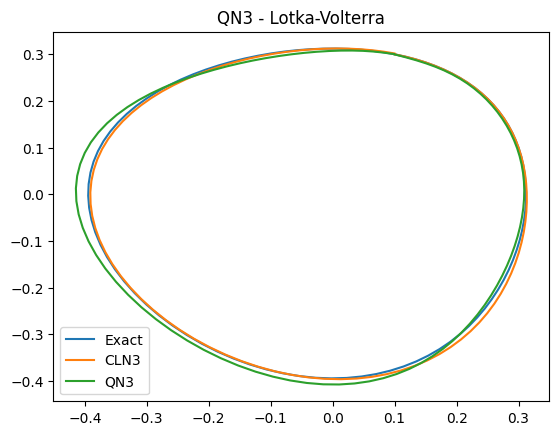

In [31]:
# Plotting the results for x1 and x2
plt.title('QN3 - Lotka-Volterra')
plt.plot(sol_exact.y[0], sol_exact.y[1], label='Exact')
plt.plot(sol_CLN3.y[0], sol_CLN3.y[1], label='CLN3')
plt.plot(sol_QN3(t)[:, 0], sol_QN3(t)[:, 1], label='QN3')
plt.legend()
# plt.grid(True)
plt.savefig("LV_N3Cheb-Phase.png") 
plt.show()

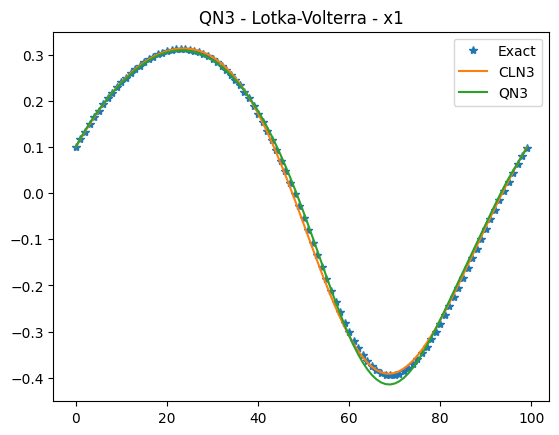

In [32]:
# Plotting the results for x1
plt.title('QN3 - Lotka-Volterra - x1')
plt.plot(sol_exact.y[0], '*',label='Exact')
plt.plot(sol_CLN3.y[0], label='CLN3')
plt.plot(sol_QN3(t)[:, 0], label='QN3')
plt.legend()
# plt.grid(True)
plt.savefig("LV_N3Cheb-x1.png") 
plt.show()

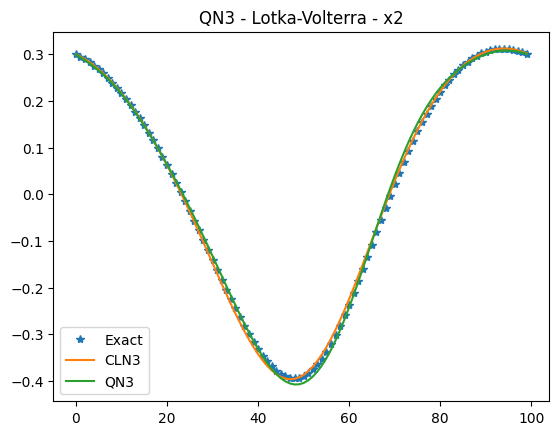

In [33]:
# Plotting the results for x2
plt.title('QN3 - Lotka-Volterra - x2')
plt.plot(sol_exact.y[1], '*',label='Exact')
plt.plot(sol_CLN3.y[1], label='CLN3')
plt.plot(sol_QN3(t)[:, 1], label='QN3')
plt.legend()
# plt.grid(True)
plt.savefig("LV_N3Cheb-x2.png")
plt.show()

In [34]:
col1QN3 = sol_QN3(t)[:, 0]
col2QN3 = sol_QN3(t)[:, 1]

import csv
file_path = 'LV-QN3.csv'

# Writing to CSV
with open(file_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['u1', 'u2'])  # Write header
    writer.writerows(zip(col1QN3, col2QN3))